In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import PercentFormatter
from scipy.stats import fisher_exact

In [122]:
df = pd.read_csv('ALL_collisions_elpaso_downtown_LPI.csv')

severity_values = {
    'K - FATAL INJURY': 13749500,
    'A - SUSPECTED SERIOUS INJURY': 1432400,
    'B - SUSPECTED MINOR INJURY': 303200,
    'C - POSSIBLE INJURY': 151600,
    'N - NOT INJURED': 0,
    '99 - UNKNOWN': 0
}

df["KABCO_USD_Value"] = df["Person_Injury_Severity"].map(severity_values).fillna(0)

df

,OBJECTID,Crash_ID,At_Intersection_Flag,Crash_Date,Crash_Severity,Crash_Time,Crash_Year,Day_of_Week,Hour_of_Day,Intersecting_Street_Name,Latitude,Longitude,Speed_Limit,Street_Name,Person_Death_Count,Person_Injury_Severity,Person_Type,KABCO_USD_Value
0,218,19105072,True,2022-09-09,N - NOT INJURED,1153,2022,FRIDAY,11 AM,N KANSAS ST,31.762075,-106.48739,30,E FRANKLIN AVE,0,N - NOT INJURED,Motorist,0
1,219,19105072,True,2022-09-09,N - NOT INJURED,1153,2022,FRIDAY,11 AM,N KANSAS ST,31.762075,-106.48739,30,E FRANKLIN AVE,0,N - NOT INJURED,Motorist,0
2,512,19138605,True,2022-09-21,N - NOT INJURED,1705,2022,WEDNESDAY,5 PM,N STANTON ST,31.761535,-106.48821,30,E FRANKLIN AVE,0,N - NOT INJURED,Motorist,0
3,513,19138605,True,2022-09-21,N - NOT INJURED,1705,2022,WEDNESDAY,5 PM,N STANTON ST,31.761535,-106.48821,30,E FRANKLIN AVE,0,N - NOT INJURED,Other,0
4,817,19173843,True,2022-10-06,N - NOT INJURED,1600,2022,THURSDAY,4 PM,W 4TH AVE,31.753145,-106.48870,30,S SANTA FE ST,0,99 - UNKNOWN,Motorist,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,27039,21265229,True,2026-02-06,N - NOT INJURED,1310,2026,FRIDAY,1 PM,W OVERLAND AVE,31.756435,-106.48974,30,S SANTA FE ST,0,N - NOT INJURED,Motorist,0
647,27385,21291499,True,2026-02-23,N - NOT INJURED,800,2026,MONDAY,8 AM,N KANSAS ST,31.762815,-106.48804,30,E MISSOURI AVE,0,N - NOT INJURED,Motorist,0
648,27386,21291499,True,2026-02-23,N - NOT INJURED,800,2026,MONDAY,8 AM,N KANSAS ST,31.762815,-106.48804,30,E MISSOURI AVE,0,N - NOT INJURED,Motorist,0
649,27387,21291499,True,2026-02-23,N - NOT INJURED,800,2026,MONDAY,8 AM,N KANSAS ST,31.762815,-106.48804,30,E MISSOURI AVE,0,N - NOT INJURED,Motorist,0


In [102]:
# Ensure datetime
df["Crash_Date"] = pd.to_datetime(df["Crash_Date"])

# Define period boundaries
bins = [
    pd.Timestamp("2022-08-26"),
    pd.Timestamp("2023-08-26"),
    pd.Timestamp("2024-08-26"),
    pd.Timestamp("2025-08-26"),
    pd.Timestamp("2026-03-05")  # exclusive upper bound
]

labels = [
    "Aug 26 2022 - Aug 25 2023",
    "Aug 26 2023 - Aug 25 2024",
    "Aug 26 2024 - Aug 25 2025",
    "Aug 26 2025 - Mar 4 2026"
]

df["period_label"] = pd.cut(
    df["Crash_Date"],
    bins=bins,
    labels=labels,
    right=False  # include left date, exclude right date
)

df

,OBJECTID,Crash_ID,At_Intersection_Flag,Crash_Date,Crash_Severity,Crash_Time,Crash_Year,Day_of_Week,Hour_of_Day,Intersecting_Street_Name,Latitude,Longitude,Speed_Limit,Street_Name,Person_Death_Count,Person_Injury_Severity,Person_Type,KABCO_USD_Value,period_label
0,218,19105072,True,2022-09-09,N - NOT INJURED,1153,2022,FRIDAY,11 AM,N KANSAS ST,31.762075,-106.48739,30,E FRANKLIN AVE,0,N - NOT INJURED,Motorist,0,Aug 26 2022 - Aug 25 2023
1,219,19105072,True,2022-09-09,N - NOT INJURED,1153,2022,FRIDAY,11 AM,N KANSAS ST,31.762075,-106.48739,30,E FRANKLIN AVE,0,N - NOT INJURED,Motorist,0,Aug 26 2022 - Aug 25 2023
2,512,19138605,True,2022-09-21,N - NOT INJURED,1705,2022,WEDNESDAY,5 PM,N STANTON ST,31.761535,-106.48821,30,E FRANKLIN AVE,0,N - NOT INJURED,Motorist,0,Aug 26 2022 - Aug 25 2023
3,513,19138605,True,2022-09-21,N - NOT INJURED,1705,2022,WEDNESDAY,5 PM,N STANTON ST,31.761535,-106.48821,30,E FRANKLIN AVE,0,N - NOT INJURED,Other,0,Aug 26 2022 - Aug 25 2023
4,817,19173843,True,2022-10-06,N - NOT INJURED,1600,2022,THURSDAY,4 PM,W 4TH AVE,31.753145,-106.48870,30,S SANTA FE ST,0,99 - UNKNOWN,Motorist,0,Aug 26 2022 - Aug 25 2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,27039,21265229,True,2026-02-06,N - NOT INJURED,1310,2026,FRIDAY,1 PM,W OVERLAND AVE,31.756435,-106.48974,30,S SANTA FE ST,0,N - NOT INJURED,Motorist,0,Aug 26 2025 - Mar 4 2026
647,27385,21291499,True,2026-02-23,N - NOT INJURED,800,2026,MONDAY,8 AM,N KANSAS ST,31.762815,-106.48804,30,E MISSOURI AVE,0,N - NOT INJURED,Motorist,0,Aug 26 2025 - Mar 4 2026
648,27386,21291499,True,2026-02-23,N - NOT INJURED,800,2026,MONDAY,8 AM,N KANSAS ST,31.762815,-106.48804,30,E MISSOURI AVE,0,N - NOT INJURED,Motorist,0,Aug 26 2025 - Mar 4 2026
649,27387,21291499,True,2026-02-23,N - NOT INJURED,800,2026,MONDAY,8 AM,N KANSAS ST,31.762815,-106.48804,30,E MISSOURI AVE,0,N - NOT INJURED,Motorist,0,Aug 26 2025 - Mar 4 2026


In [103]:
groups = df.groupby('period_label')

In [104]:
df.query('period_label == "Aug 26 2022 - Aug 25 2023"').sort_values(['Person_Injury_Severity', 'Crash_Date'], ascending=True)

,OBJECTID,Crash_ID,At_Intersection_Flag,Crash_Date,Crash_Severity,Crash_Time,Crash_Year,Day_of_Week,Hour_of_Day,Intersecting_Street_Name,Latitude,Longitude,Speed_Limit,Street_Name,Person_Death_Count,Person_Injury_Severity,Person_Type,KABCO_USD_Value,period_label
4,817,19173843,True,2022-10-06,N - NOT INJURED,1600,2022,THURSDAY,4 PM,W 4TH AVE,31.753145,-106.48870,30,S SANTA FE ST,0,99 - UNKNOWN,Motorist,0,Aug 26 2022 - Aug 25 2023
11,883,19173000,True,2022-10-12,N - NOT INJURED,1914,2022,WEDNESDAY,7 PM,E MILLS AVE,31.761195,-106.48522,35,N CAMPBELL ST,0,99 - UNKNOWN,Motorist,0,Aug 26 2022 - Aug 25 2023
40,2051,19292160,True,2022-12-08,N - NOT INJURED,928,2022,THURSDAY,9 AM,E OVERLAND AVE,31.757385,-106.48663,30,S MESA ST,0,99 - UNKNOWN,Motorist,0,Aug 26 2022 - Aug 25 2023
181,7351,19298284,True,2022-12-15,N - NOT INJURED,845,2022,THURSDAY,8 AM,W 4TH AVE,31.753145,-106.48870,30,S SANTA FE ST,0,99 - UNKNOWN,Motorist,0,Aug 26 2022 - Aug 25 2023
59,2529,19334999,True,2023-01-12,N - NOT INJURED,1900,2023,THURSDAY,7 PM,E SAN ANTONIO AVE,31.758755,-106.48481,35,S KANSAS ST,0,99 - UNKNOWN,Motorist,0,Aug 26 2022 - Aug 25 2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,6593,19700531,True,2023-08-13,N - NOT INJURED,1946,2023,SUNDAY,7 PM,N CAMPBELL ST,31.760485,-106.48462,30,TEXAS AVE,0,N - NOT INJURED,Motorist,0,Aug 26 2022 - Aug 25 2023
167,6606,19702948,True,2023-08-14,N - NOT INJURED,1045,2023,MONDAY,10 AM,S CAMPBELL ST,31.758095,-106.48357,35,E OVERLAND AVE,0,N - NOT INJURED,Motorist,0,Aug 26 2022 - Aug 25 2023
168,6607,19702948,True,2023-08-14,N - NOT INJURED,1045,2023,MONDAY,10 AM,S CAMPBELL ST,31.758095,-106.48357,35,E OVERLAND AVE,0,N - NOT INJURED,Motorist,0,Aug 26 2022 - Aug 25 2023
222,8483,19720915,True,2023-08-24,N - NOT INJURED,740,2023,THURSDAY,7 AM,N KANSAS ST,31.760635,-106.48605,30,N KANSAS ST,0,N - NOT INJURED,Motorist,0,Aug 26 2022 - Aug 25 2023


In [105]:
counts = (
    df
    .groupby(["period_label", "Person_Injury_Severity"])
    .size()
    .reset_index(name="count")
    .pivot(index="period_label", columns="Person_Injury_Severity", values="count")
)

counts

Person_Injury_Severity,99 - UNKNOWN,A - SUSPECTED SERIOUS INJURY,B - SUSPECTED MINOR INJURY,C - POSSIBLE INJURY,N - NOT INJURED
period_label,,,,,
Aug 26 2022 - Aug 25 2023,13.0,1.0,24.0,15.0,171.0
Aug 26 2023 - Aug 25 2024,9.0,4.0,31.0,13.0,162.0
Aug 26 2024 - Aug 25 2025,5.0,NaN,4.0,9.0,114.0
Aug 26 2025 - Mar 4 2026,2.0,NaN,7.0,6.0,61.0


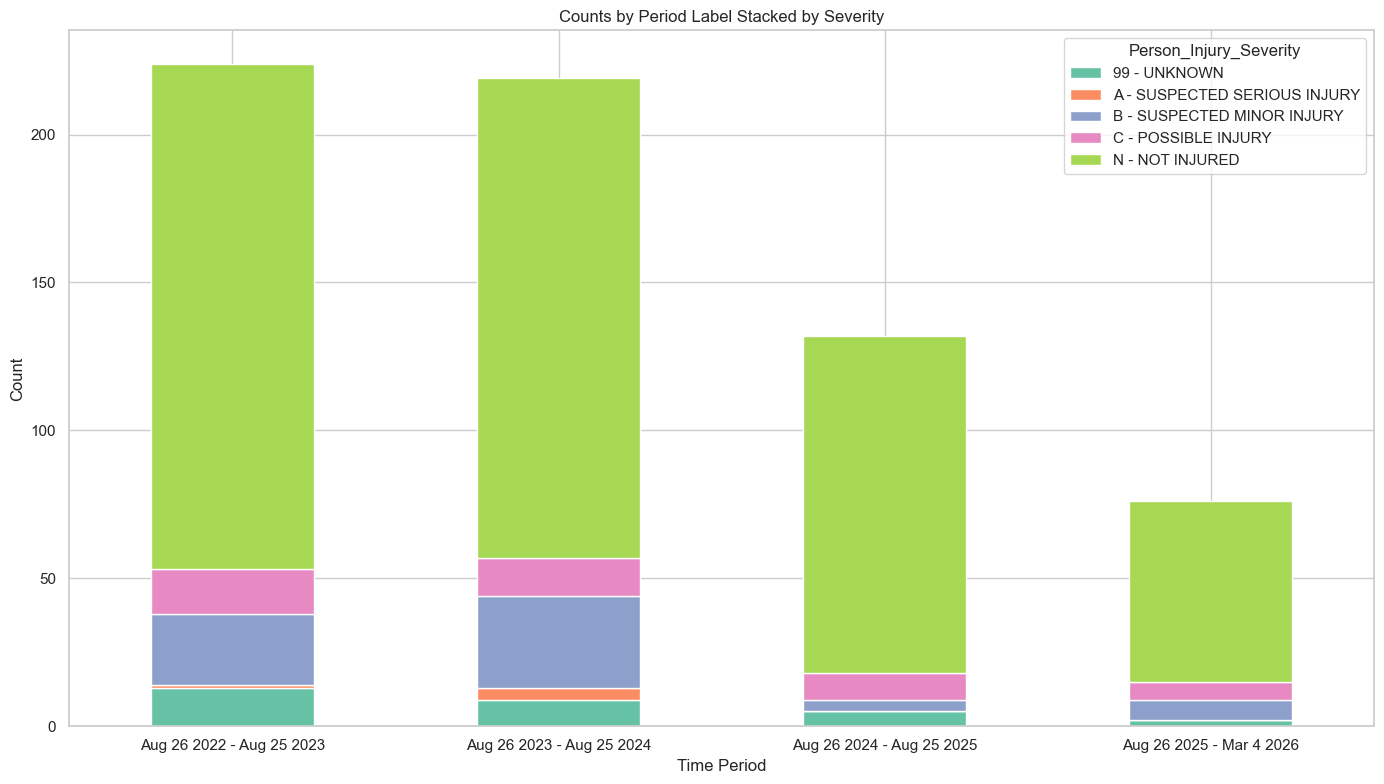

In [106]:
sns.set_theme(style="whitegrid")

# Create Set2 color palette
colors = sns.color_palette("Set2", n_colors=len(counts.columns))

ax = counts.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 8),
    color=colors   # 👈 Apply Set2 colors
)

ax.set_xlabel("Time Period")
ax.set_ylabel("Count")
ax.set_title("Counts by Period Label Stacked by Severity")

# Keep x labels horizontal
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")

plt.tight_layout()
plt.show()

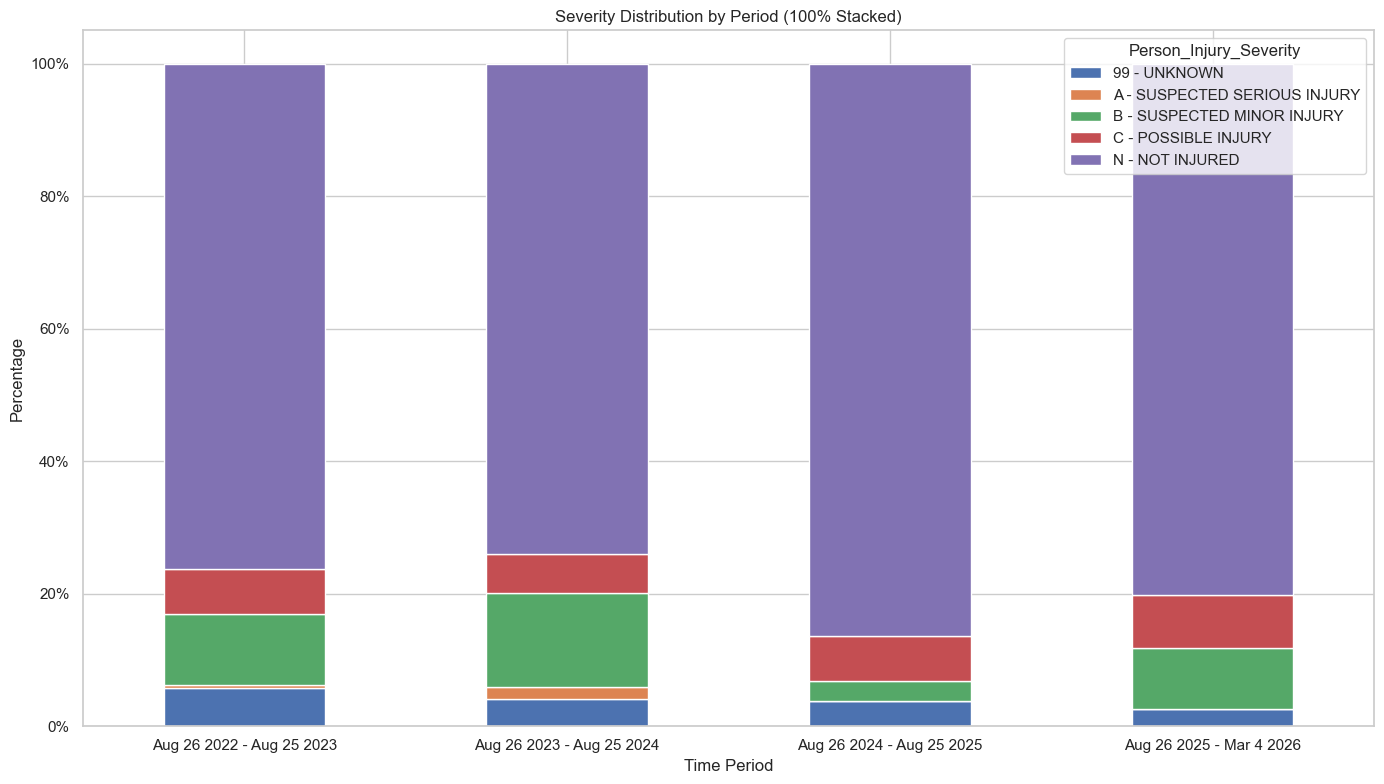

In [107]:
percentages = counts.div(counts.sum(axis=1), axis=0)

sns.set_theme(style="whitegrid")

ax = percentages.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 8)
)

ax.set_xlabel("Time Period")
ax.set_ylabel("Percentage")
ax.set_title("Severity Distribution by Period (100% Stacked)")

# Format y-axis as percentages
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Angle x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")

plt.tight_layout()
plt.show()

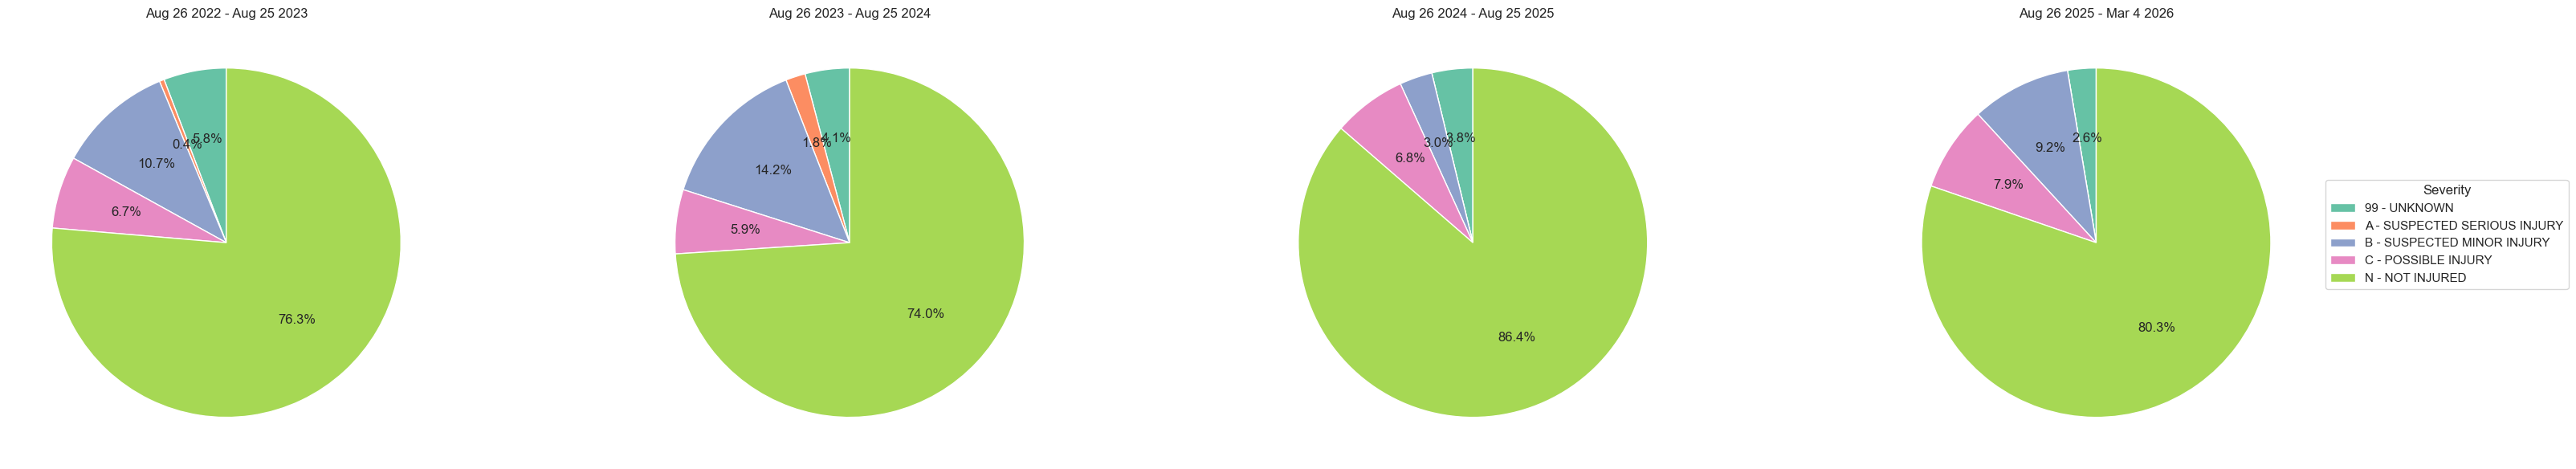

In [108]:
# Remove zero-sum rows
percentages = percentages[percentages.sum(axis=1) > 0]

n_periods = len(percentages)

fig, axes = plt.subplots(1, n_periods, figsize=(8 * n_periods, 6))

if n_periods == 1:
    axes = [axes]

# Consistent colors across all pies
colors = sns.color_palette("Set2", n_colors=len(percentages.columns))

def autopct_no_zero(p):
    return f"{p:.1f}%" if p > 0 else ""

for ax, (period, row) in zip(axes, percentages.iterrows()):
    
    values = np.nan_to_num(row.values.astype(float))
    
    wedges, texts, autotexts = ax.pie(
        values,
        labels=None,
        autopct=autopct_no_zero,   # ✅ hides 0.0%
        startangle=90,
        colors=colors
    )
    
    ax.set_title(period)

fig.legend(
    wedges,
    percentages.columns,
    title="Severity",
    loc="center right",
    bbox_to_anchor=(1.05, 0.5)
)

plt.tight_layout()
plt.show()

C:\Users\CastroJG\AppData\Local\Temp\ipykernel_19376\1296887406.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


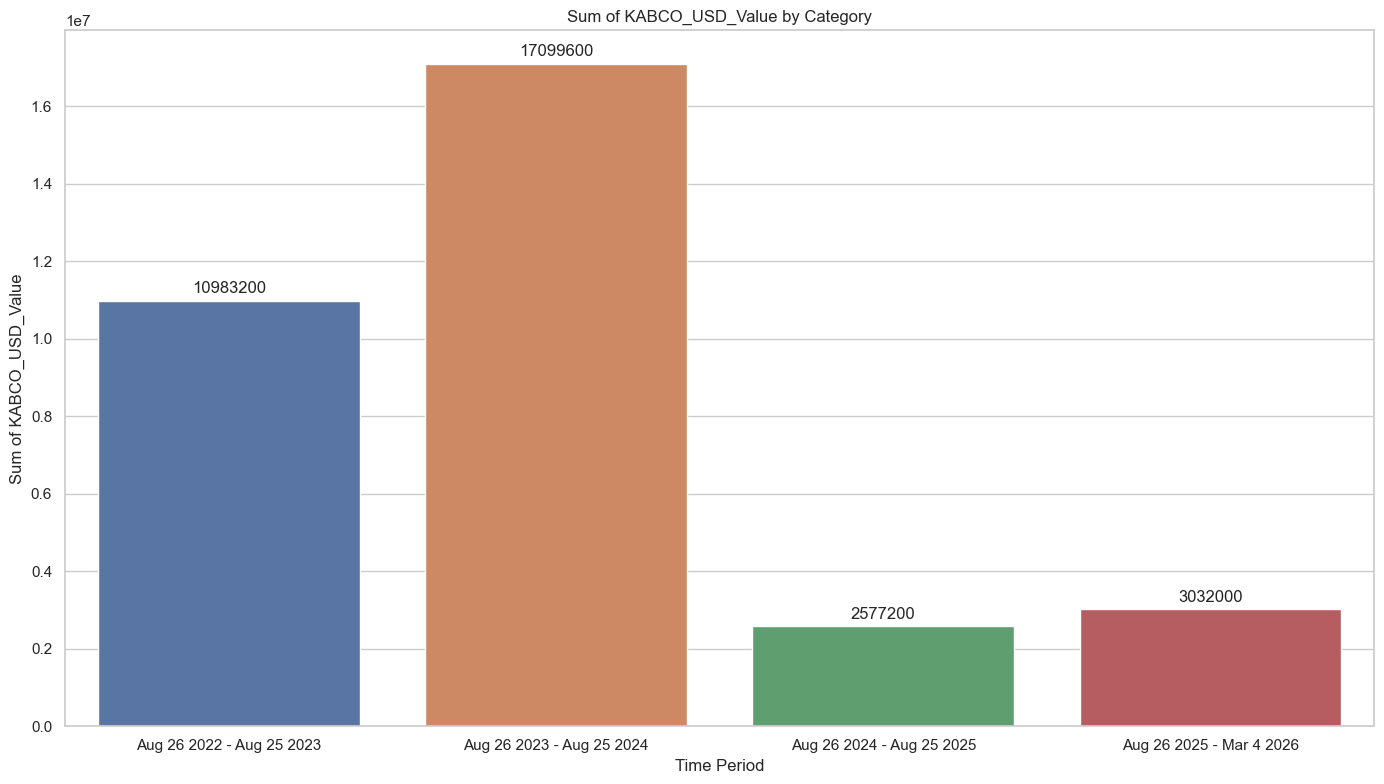

In [112]:
# Compute the data first
kabco_sum = groups["KABCO_USD_Value"].sum().reset_index()
kabco_sum.columns = ["KABCO_USD_Value", "sum_kabco"]

# Plot
plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=kabco_sum,
    x="KABCO_USD_Value",
    y="sum_kabco",
    ci=None
)

# Axis labels and title
ax.set_xlabel("Time Period")
ax.set_ylabel("Sum of KABCO_USD_Value")
ax.set_title("Sum of KABCO_USD_Value by Category")

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [113]:
finalized_df = df.copy()

# Avoid log(0) — all your KABCO values are > 0
finalized_df['KABCO_log'] = np.log(finalized_df['KABCO_USD_Value'])

# Split pre/post
pre_log = finalized_df[finalized_df['Crash_Date'] < '2024-08-26']['KABCO_log']
post_log = finalized_df[finalized_df['Crash_Date'] >= '2024-08-26']['KABCO_log']

# Example: Bootstrap CI on log scale
diffs = []
for _ in range(10000):
    pre_sample = np.random.choice(pre_log, size=len(pre_log), replace=True)
    post_sample = np.random.choice(post_log, size=len(post_log), replace=True)
    diffs.append(np.median(pre_sample) - np.median(post_sample))

ci_lower, ci_upper = np.percentile(diffs, [20.0, 80.0])
print(f"80% CI for median log(KABCO) difference: {ci_lower:.2f} to {ci_upper:.2f}")

c:\Users\CastroJG\AppData\Local\ESRI\conda\envs\arcgispro-py3-clone\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\CastroJG\AppData\Local\Temp\ipykernel_19376\3866873355.py:15: RuntimeWarning: invalid value encountered in scalar subtract
  diffs.append(np.median(pre_sample) - np.median(post_sample))


80% CI for median log(KABCO) difference: nan to nan


In [114]:
import numpy as np
from scipy.stats import fisher_exact

# 1️⃣ Aggregate counts by Period_Label and Severity
severity_counts = df.groupby(['period_label','Crash_Severity']).size().unstack(fill_value=0)

# 2️⃣ Collapse categories: Severe (A/B) vs Non-severe (C/N)
severity_counts['Severe'] = severity_counts.get('A - SUSPECTED SERIOUS INJURY',0) + \
                            severity_counts.get('B - SUSPECTED MINOR INJURY',0)
severity_counts['Non_Severe'] = severity_counts.get('C - POSSIBLE INJURY',0) + \
                                severity_counts.get('N - NOT INJURED',0)

table_2x2 = severity_counts[['Severe','Non_Severe']].copy()

# Ensure consistent ordering (important)
table_2x2 = table_2x2.sort_index()

# Explicitly define periods
pre_periods = [
    "Aug 26 2022 - Aug 25 2023",
    "Aug 26 2023 - Aug 25 2024"
]

post_periods = [
    "Aug 26 2024 - Aug 25 2025",
    "Aug 26 2025 - Mar 4 2026"
]

# Aggregate counts
pre = table_2x2.loc[pre_periods].sum().values
post = table_2x2.loc[post_periods].sum().values

# Build contingency table
contingency = np.array([pre, post])

print("Contingency Table:")
print(contingency)

# Fisher's Exact Test
oddsratio, p_value = fisher_exact(contingency, alternative='two-sided')

print(f"\nFisher's exact test:")
print(f"Odds ratio = {oddsratio:.3f}")
print(f"P-value = {p_value:.4f}")

Contingency Table:
[[118 323]
 [ 28 180]]

Fisher's exact test:
Odds ratio = 2.349
P-value = 0.0001


In [115]:
table_2x2

Crash_Severity,Severe,Non_Severe
period_label,,
Aug 26 2022 - Aug 25 2023,49,175
Aug 26 2023 - Aug 25 2024,69,148
Aug 26 2024 - Aug 25 2025,13,119
Aug 26 2025 - Mar 4 2026,15,61


In [116]:
pre

array([118, 323])

In [117]:
post

array([ 28, 180])

In [118]:
severity_counts

Crash_Severity,99 - UNKNOWN,A - SUSPECTED SERIOUS INJURY,B - SUSPECTED MINOR INJURY,C - POSSIBLE INJURY,N - NOT INJURED,Severe,Non_Severe
period_label,,,,,,,
Aug 26 2022 - Aug 25 2023,0,2,47,34,141,49,175
Aug 26 2023 - Aug 25 2024,2,13,56,22,126,69,148
Aug 26 2024 - Aug 25 2025,0,0,13,23,96,13,119
Aug 26 2025 - Mar 4 2026,0,0,15,16,45,15,61


In [119]:
df['Full_Intersection'] = df['Street_Name'] + " & " + df['Intersecting_Street_Name']

# Aggregate in case there are multiple rows per combo
agg = (
    df.groupby(["period_label", "Street_Name", "Intersecting_Street_Name", "Full_Intersection"], as_index=False)
      .agg({"KABCO_USD_Value": "sum"})
)

# Pivot to wide format

pivot = agg.pivot(
    index="Full_Intersection",
    columns="period_label",
    values="KABCO_USD_Value"
).fillna(0)

pivot

period_label,Aug 26 2022 - Aug 25 2023,Aug 26 2023 - Aug 25 2024,Aug 26 2024 - Aug 25 2025,Aug 26 2025 - Mar 4 2026
Full_Intersection,,,,
CAMPBELL ST & MYRTLE AVE,0.0,0.0,0.0,0.0
E 4TH AVE & S OREGON ST,0.0,0.0,0.0,0.0
E FRANKLIN AVE & N KANSAS ST,606400.0,303200.0,0.0,303200.0
E FRANKLIN AVE & N STANTON ST,0.0,0.0,454800.0,0.0
E MAIN DR & UNKNOWN,0.0,0.0,0.0,0.0
E MAIN ST & N CAMPBELL ST,0.0,0.0,0.0,0.0
E MAIN ST & N KANSAS ST,151600.0,0.0,0.0,0.0
E MILLS AVE & N KANSAS ST,0.0,0.0,0.0,0.0
E MILLS AVE & STANTON ST,0.0,1432400.0,0.0,0.0


In [120]:
agg

,period_label,Street_Name,Intersecting_Street_Name,Full_Intersection,KABCO_USD_Value
0,Aug 26 2022 - Aug 25 2023,CAMPBELL ST,MYRTLE AVE,CAMPBELL ST & MYRTLE AVE,0
1,Aug 26 2022 - Aug 25 2023,E 4TH AVE,S OREGON ST,E 4TH AVE & S OREGON ST,0
2,Aug 26 2022 - Aug 25 2023,E FRANKLIN AVE,N KANSAS ST,E FRANKLIN AVE & N KANSAS ST,606400
3,Aug 26 2022 - Aug 25 2023,E FRANKLIN AVE,N STANTON ST,E FRANKLIN AVE & N STANTON ST,0
4,Aug 26 2022 - Aug 25 2023,E MAIN ST,N KANSAS ST,E MAIN ST & N KANSAS ST,151600
...,...,...,...,...,...
106,Aug 26 2025 - Mar 4 2026,S OREGON ST,E 4TH AVE,S OREGON ST & E 4TH AVE,151600
107,Aug 26 2025 - Mar 4 2026,S SANTA FE ST,US 85,S SANTA FE ST & US 85,0
108,Aug 26 2025 - Mar 4 2026,S SANTA FE ST,W OVERLAND AVE,S SANTA FE ST & W OVERLAND AVE,0
109,Aug 26 2025 - Mar 4 2026,STANTON ST,TEXAS AVE,STANTON ST & TEXAS AVE,303200


In [71]:
pivot.index.name = "Intersection"
pivot.columns.name = "Time Period"
pivot

Time Period,Aug 26 2022 - Aug 25 2023,Aug 26 2023 - Aug 25 2024,Aug 26 2024 - Aug 25 2025
Intersection,,,
N CAMPBELL ST & E MILLS AVE,5300.0,246900.0,0.0
N CAMPBELL ST & E SAN ANTONIO AVE,0.0,246900.0,118000.0
N CAMPBELL ST & TEXAS AVE,0.0,0.0,118000.0
N KANSAS ST & E FRANKLIN AVE,0.0,1254700.0,0.0
N KANSAS ST & TEXAS AVE,118000.0,0.0,0.0
N OREGON ST & W FRANKLIN AVE,0.0,3764100.0,0.0
N STANTON ST & TEXAS AVE,1254700.0,0.0,0.0
S KANSAS ST & E OVERLAND AVE,5300.0,0.0,246900.0
S OREGON ST & E FOURTH AVE,5300.0,0.0,0.0


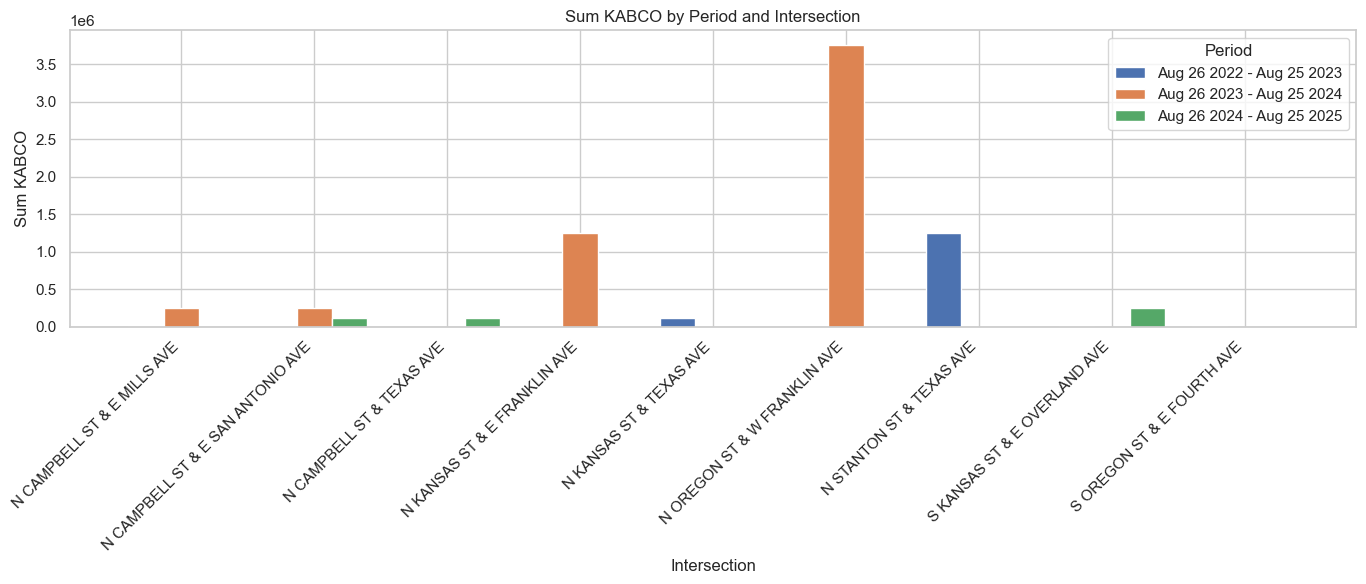

'\nFigure X shows a grouped (side-by-side) bar chart comparing the sum of KABCO crash severity values across intersections for the specified analysis period(s). \nEach group along the x-axis represents an individual intersection, labeled by street names only. Within each group, separate bars correspond to different\nperiods, allowing direct comparison of total crash severity at the same location over time. The height of each bar reflects the cumulative KABCO value, with \nhigher bars indicating greater overall crash severity at that intersection during the given period. This visualization highlights spatial differences in \ncrash severity and makes it easier to identify intersections with disproportionately high cumulative severity.\n'

In [51]:
# ---- Plot ----
x = np.arange(len(pivot.index))
bar_width = 0.8 / len(pivot.columns)

plt.figure(figsize=(14, 6))

for i, period in enumerate(pivot.columns):
    plt.bar(
        x + i * bar_width,
        pivot[period],
        width=bar_width,
        label=period
    )

plt.xticks(
    x + bar_width * (len(pivot.columns) - 1) / 2,
    pivot.index,
    rotation=45,
    ha="right"
)

plt.ylabel("Sum KABCO")
plt.xlabel("Intersection")
plt.title("Sum KABCO by Period and Intersection")
plt.legend(title="Period")

plt.tight_layout()
plt.show()
"""
Figure X shows a grouped (side-by-side) bar chart comparing the sum of KABCO crash severity values across intersections for the specified analysis period(s). 
Each group along the x-axis represents an individual intersection, labeled by street names only. Within each group, separate bars correspond to different
periods, allowing direct comparison of total crash severity at the same location over time. The height of each bar reflects the cumulative KABCO value, with 
higher bars indicating greater overall crash severity at that intersection during the given period. This visualization highlights spatial differences in 
crash severity and makes it easier to identify intersections with disproportionately high cumulative severity.
"""